In [1]:
%load_ext autoreload
%autoreload 2

#### Statistical Comparison between particle swarm optimization and genetic algorithm
 * Task: 10-D Rastrigin function

##### 1 Implement PSO and GA

In [2]:
import numpy as np
import pyswarms as ps

# Define the Rastrigin function
def rastrigin(x):
    A = 10
    return A * x.shape[1] + np.sum(x**2 - A * np.cos(2 * np.pi * x), axis=1)

# PSO parameters
dimensions = 10
bounds = (np.full(dimensions, -5.12), np.full(dimensions, 5.12))
# Apply linearly decreasing inertia weight from 0.9 to 0.1 over the iterations
options = {'c1': 2.05, 'c2': 2.05, 'w': 0.9}  # initial w, will be updated each iteration
n_particles = 20
iters = 200

# Store best results from each run
pso_best_costs = []

for run in range(10):
    # Custom optimizer loop to apply linearly decreasing inertia
    optimizer = ps.single.GlobalBestPSO(
        n_particles=n_particles,
        dimensions=dimensions,
        options=options,
        bounds=bounds
    )
    # Store best cost for this run
    best_cost = None
    for i in range(iters):
        # Linearly decrease inertia weight
        w = 0.9 - (0.5 * i / (iters - 1))
        optimizer.options['w'] = w
        cost, pos = optimizer.optimize(rastrigin, iters=1, verbose=False)
        if best_cost is None or cost < best_cost:
            best_cost = cost
    pso_best_costs.append(best_cost)


print("Best costs from 10 PSO runs on 10D Rastrigin function:")
print(pso_best_costs)


Best costs from 10 PSO runs on 10D Rastrigin function:
[8.19615752316831, 7.959727684312369, 4.625243564962972, 16.131041669493257, 4.016009022028101, 12.296623281760375, 9.384072633589156, 6.697709980042632, 5.970101655413146, 19.55678106280368]


In [3]:
import pygad

# Define the Rastrigin function for pygad (single solution)
def rastrigin_single(ga_instance, solution, solution_idx):
    A = 10
    x = np.array(solution)
    return -(A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x)))  # negative for maximization

# GA parameters
dimensions = 10
ga_num_generations = 200
ga_num_parents_mating = 10
ga_sol_per_pop = 20
ga_init_range_low = -5.12
ga_init_range_high = 5.12

ga_best_costs = []

for run in range(10):
    ga_instance = pygad.GA(
        num_generations=ga_num_generations,
        num_parents_mating=ga_num_parents_mating,
        fitness_func=rastrigin_single,
        sol_per_pop=ga_sol_per_pop,
        num_genes=dimensions,
        init_range_low=ga_init_range_low,
        init_range_high=ga_init_range_high,
        mutation_percent_genes=10,
        mutation_type="random",
        crossover_type="single_point",
        gene_type=float,
        stop_criteria=None
    )
    ga_instance.run()
    # Get best solution (remember: fitness is negative cost)
    solution, solution_fitness, solution_idx = ga_instance.best_solution()
    best_cost = -solution_fitness
    ga_best_costs.append(best_cost)

print("Best costs from 10 GA runs on 10D Rastrigin function:")
print(ga_best_costs)


d:\Anaconda\lib\site-packages\pygad\pygad.py:1139: UserWarning: The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.
  warnings.warn("The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.")


Best costs from 10 GA runs on 10D Rastrigin function:
[3.3171488128230777, 3.289941493655462, 4.258123059247126, 2.6169079068638155, 4.690089057904217, 6.0299455233903245, 2.953377980438759, 1.7035939928933743, 4.131133893388153, 3.592306093856166]


#### 2 Statistical Comparison using T-Test

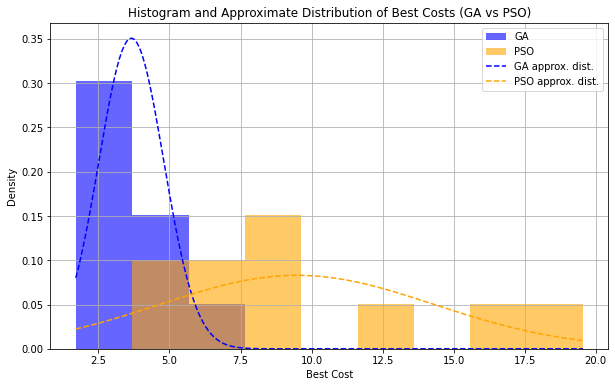

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Plot histograms
plt.figure(figsize=(10,6))
bins = np.linspace(
    min(min(ga_best_costs), min(pso_best_costs)),
    max(max(ga_best_costs), max(pso_best_costs)),
    10
)

plt.hist(ga_best_costs, bins=bins, alpha=0.6, color='blue', label='GA', density=True)
plt.hist(pso_best_costs, bins=bins, alpha=0.6, color='orange', label='PSO', density=True)

# Fit and plot normal distributions
x = np.linspace(bins[0], bins[-1], 200)
ga_mu, ga_std = np.mean(ga_best_costs), np.std(ga_best_costs)
pso_mu, pso_std = np.mean(pso_best_costs), np.std(pso_best_costs)

plt.plot(x, norm.pdf(x, ga_mu, ga_std), color='blue', linestyle='--', label='GA approx. dist.')
plt.plot(x, norm.pdf(x, pso_mu, pso_std), color='orange', linestyle='--', label='PSO approx. dist.')

plt.xlabel('Best Cost')
plt.ylabel('Density')
plt.title('Histogram and Approximate Distribution of Best Costs (GA vs PSO)')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
from scipy.stats import ttest_rel

# Perform paired t-test
t_stat, p_value = ttest_rel(ga_best_costs, pso_best_costs)

print("Paired t-test results:")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

Paired t-test results:
t-statistic: -3.4720
p-value: 0.0070
